In [1]:
import numpy as np
import matplotlib.pyplot as plt
import strawberryfields as sf
from strawberryfields.ops import*
import qkd_sf as qsf
from importlib import reload

In [2]:
def reload_protocols():
    reload(qsf)

## Parameters for RR

In [7]:
eta = 0.1
keylen = 1000
sigma_grid = np.linspace(0.001,10,21)
var_a_grid = sigma_grid**2
V=0.1

### Mutual Information

In [8]:
reload_protocols()
I_RR, I_x_RR, I_p_RR = qsf.MC_I_AB(var_a_grid, eta, keylen, V)

Progress: 21/21

In [9]:
reload_protocols()
th_I_RR, th_I_x_RR, th_I_p_RR = qsf.theoretical_I_AB(sigma_grid**2, eta, V)

### Holevo Bound

In [14]:
reload_protocols()
holevo_th_grid_RR = np.zeros((len(var_a_grid)))

for i,sigma in enumerate(sigma_grid):
    chi, chi_x, chi_p = qsf.holevo_RR(sigma**2, eta, V)
    holevo_th_grid_RR[i] = chi_x
    print(f"\rProgress: {i+1}/{len(sigma_grid)}", end="", flush=True)

Progress: 21/21

### Plot Mutual Information & Holevo Bound

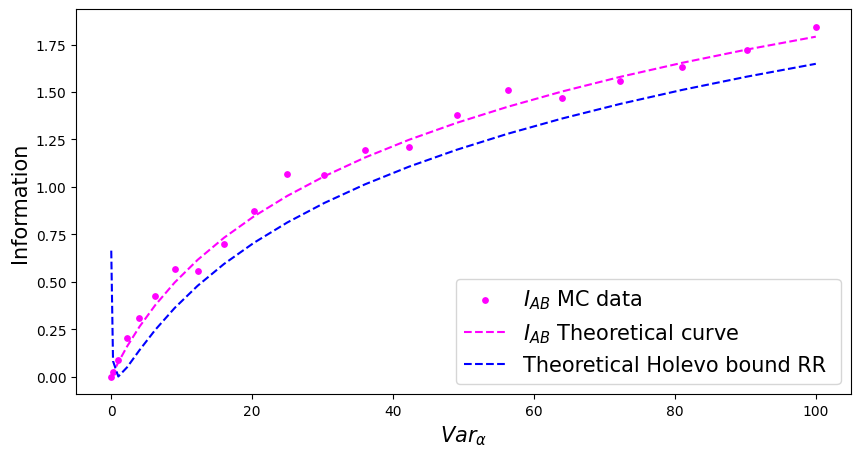

In [15]:
reload_protocols()

b = 0.95

fig = plt.figure(figsize=(10,5), dpi=100)
plt.scatter(var_a_grid, I_x_RR, s=15, color = 'magenta', label=r'$I_{AB}$ MC data')
plt.plot(var_a_grid, th_I_x_RR, '--', color='magenta', label=r'$I_{AB}$ Theoretical curve')
plt.plot(var_a_grid, holevo_th_grid_RR, 'b--', label = 'Theoretical Holevo bound RR ')
plt.xlabel(r'$Var_{{\alpha}}$', fontsize=15)
plt.ylabel(r'Information', fontsize=15)
plt.legend(fontsize=15)



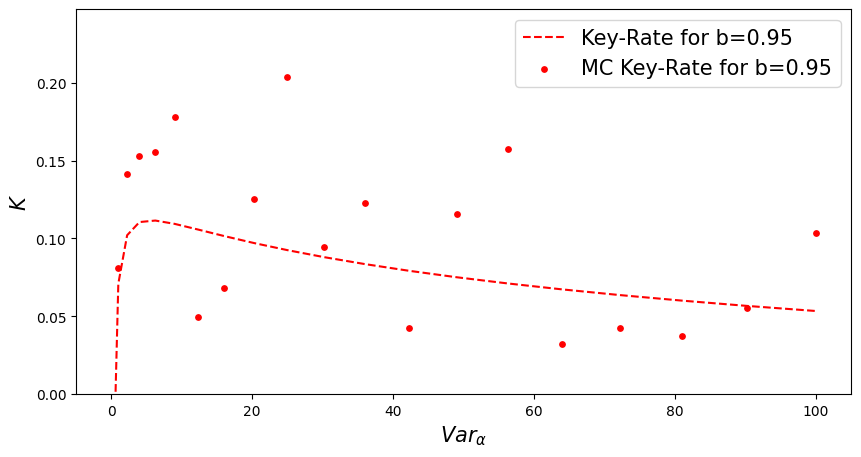

In [16]:
fig = plt.figure(figsize=(10,5), dpi=100)
plt.plot(var_a_grid, qsf.key_rate(b,  th_I_x_RR, holevo_th_grid_RR), '--r', label = f'Key-Rate for b={b}')
plt.scatter(var_a_grid, qsf.key_rate(b, I_x_RR, holevo_th_grid_RR), s=15, color = 'red', label = f'MC Key-Rate for b={b}')
plt.xlabel(r'$Var_{{\alpha}}$', fontsize=15)
plt.ylim(0)
plt.ylabel(r'$K$', fontsize=15)
plt.legend(fontsize=15)


## Parameters for DR protocol

In [27]:
eta = 0.6
keylen = 1000
sigma_grid = np.linspace(0.001,10,21)
var_a_grid = sigma_grid**2
V=1

### Mutual Information

In [28]:
reload_protocols()
I_DR, I_x_DR, I_p_DR = qsf.MC_I_AB(var_a_grid, eta, keylen, V)

Progress: 21/21

In [29]:
reload_protocols()
th_I_DR, th_I_x_DR, th_I_p_DR = qsf.theoretical_I_AB(sigma_grid**2, eta, V)

### Holevo Bound

In [30]:
import numpy as np

def G(x):
    if x <= 0:
        return 0.0
    return (x + 1) * np.log2(x + 1) - x * np.log2(x)


def symplectic_eigenvalue(gamma):
    return np.sqrt(np.linalg.det(gamma))


def eve_covariance(var_a, eta):
    V_E = 1 + (1 - eta) * var_a

    return np.array([
        [V_E, 0],
        [0, V_E]
    ])


def eve_conditional_covariance_DR(var_a, eta):
    V_E = 1 + (1 - eta) * var_a

    # Alice reveals only one quadrature
    return np.array([
        [1, 0],
        [0, V_E]
    ])


def chi_DR(var_a, eta):

    # Unconditional Eve state
    gamma_E = eve_covariance(var_a, eta)
    lambda_E = symplectic_eigenvalue(gamma_E)

    # Eve conditioned on Alice's measured quadrature
    gamma_E_cond = eve_conditional_covariance_DR(var_a, eta)
    lambda_cond = symplectic_eigenvalue(gamma_E_cond)

    S_E = G((lambda_E - 1) / 2)
    S_E_cond = G((lambda_cond - 1) / 2)

    chi = S_E - S_E_cond

    return chi, lambda_E, lambda_cond

In [38]:
reload_protocols()
holevo_th_grid_DR = np.zeros((len(var_a_grid)))

for i,sigma in enumerate(sigma_grid):
    chi = chi_DR(sigma**2, eta)[0]
    holevo_th_grid_DR[i] = chi
    print(f"\rProgress: {i+1}/{len(sigma_grid)}", end="", flush=True)

Progress: 21/21

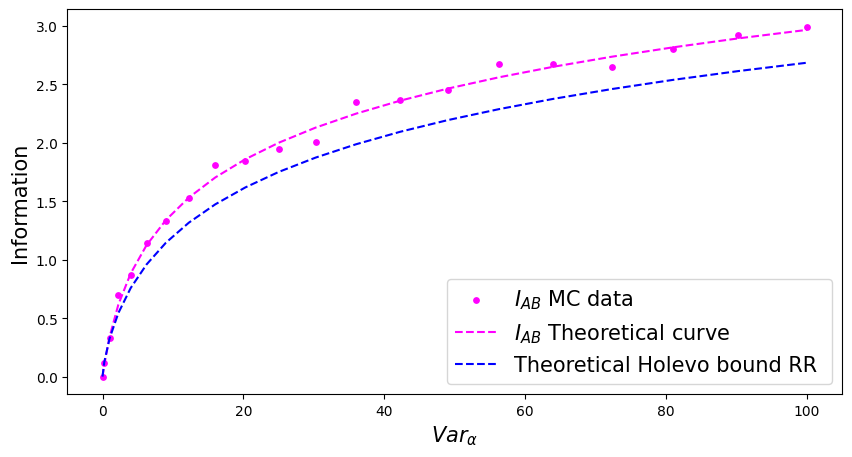

In [39]:
reload_protocols()

b = 0.95

fig = plt.figure(figsize=(10,5), dpi=100)
plt.scatter(var_a_grid, I_x_DR, s=15, color = 'magenta', label=r'$I_{AB}$ MC data')
plt.plot(var_a_grid, th_I_x_DR, '--', color='magenta', label=r'$I_{AB}$ Theoretical curve')
plt.plot(var_a_grid, holevo_th_grid_DR, 'b--', label = 'Theoretical Holevo bound RR ')
plt.xlabel(r'$Var_{{\alpha}}$', fontsize=15)
plt.ylabel(r'Information', fontsize=15)
plt.legend(fontsize=15)

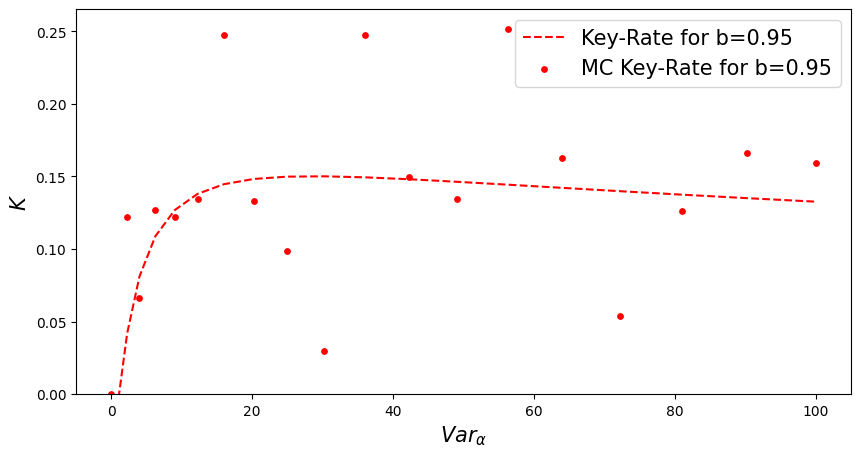

In [40]:
fig = plt.figure(figsize=(10,5), dpi=100)
plt.plot(var_a_grid, qsf.key_rate(b,  th_I_x_DR, holevo_th_grid_DR), '--r', label = f'Key-Rate for b={b}')
plt.scatter(var_a_grid, qsf.key_rate(b, I_x_DR, holevo_th_grid_DR), s=15, color = 'red', label = f'MC Key-Rate for b={b}')
plt.xlabel(r'$Var_{{\alpha}}$', fontsize=15)
plt.ylim(0)
plt.ylabel(r'$K$', fontsize=15)
plt.legend(fontsize=15)
